# Filter low quality paraphrases
Find out how many paraphrases are of low quality and filter them out.

Load paraphrases.

In [38]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from pathlib import Path

# sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization.datasets import *
from genai_detection.config import CONFIG
from functools import partial
import gc
import datetime
import json
import textwrap
import pyreadstat
import collections
from datasets import load_from_disk

In [ ]:
# student essays test
path2json1 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json"
)

# student essays test for sim syn
path2json2 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json"
)

# detection scenarios Student essays
path2json3 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json"
)

# new prompt
path2newjson = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "dumps/impostor_naive_llm.json"
)

store_length = pd.DataFrame(
    columns=[
        "paraphraser",
        "prompt",
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "post_process_len_perc(qwen)",
    ]
)
reference_pair_ids = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "reference_text"]
)
store_garbage_texts = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "paraphraser", "garbage"]
)
garbage_texts = ["I sorry, but I can't help with that."]

extremest_len_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
    ]
)

extremest_post_processed_len_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
    ]
)

perfect_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
    ]
)


# read json file
for path2json in [path2json1, path2json2, path2json3]:
    print("Reading json file:", path2json)
    with open(path2json, "r", encoding="utf-8") as f:
        df = json.load(f)

    for i in range(len(df)):  # uppermost list level: dictionary
        item = df[i]
        if "artificial_generation" in item and item["artificial_generation"]:
            # print("Skipping item", i, "because 'artificial_generation' is True, i.e. pair was generated.")
            continue
        if (
            "impostor_dict_naive_llm" not in item
            or item["impostor_dict_naive_llm"] is None
        ):
            # print("Skipping item", i, "because no 'impostor_dict_naive_llm' key found.")
            continue
        pair_dict = item["impostor_dict_naive_llm"]["text_pair_0"]  # dict with two keys

        for (
            no_in_pair,
            imp_dict,
        ) in pair_dict.items():  # dict containing reference text and paraphrases
            reference_text = imp_dict["reference_text"]
            paraphrases_dict = imp_dict["paraphrases"]
            # calculate word counts (split on whitespace)
            ref_len = len(reference_text.split())

            # add reference text info (ensuring no duplicates)
            reference_pair_ids = pd.concat(
                [
                    reference_pair_ids,
                    pd.DataFrame(
                        [
                            {
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": no_in_pair,  # "0" or "1"
                                "reference_text": reference_text,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

            for impostor_name, para in paraphrases_dict.items():  # impostors
                split_name = impostor_name.split("_")
                paraphraser = split_name[-1]
                prompt = split_name[2]

                para_len = len(para.split())
                # check for garbage
                garbage = any(g in para for g in garbage_texts)

                relative_len_perc = np.round((para_len / ref_len) * 100, 2)

                processed_text_len_perc = relative_len_perc
                if "</think>" in para:
                    temp = para.split("</think>")[-1].strip()
                    processed_text_len_perc = np.round(
                        (len(temp.split()) / ref_len) * 100, 2
                    )

                    if processed_text_len_perc > 110 or processed_text_len_perc < 10:
                        extremest_post_processed_len_paraphrases = pd.concat(
                            [
                                extremest_post_processed_len_paraphrases,
                                pd.DataFrame(
                                    [
                                        {
                                            "reference_text_length": ref_len,
                                            "paraphrase_length": para_len,
                                            "smaller700": para_len < 700,
                                            "paraphraser": paraphraser,
                                            "prompt": prompt,
                                            "reference_pair_id": i,  # position in the outermost list
                                            "pair_id": no_in_pair,  # "0" or "1"
                                            "realtive_len_perc": relative_len_perc,
                                            "post_process_len_perc(qwen)": processed_text_len_perc,
                                            "paraphrase": temp,
                                        }
                                    ]
                                ),
                            ],
                            ignore_index=True,
                        )

                # add length info
                store_length = pd.concat(
                    [
                        store_length,
                        pd.DataFrame(
                            [
                                {
                                    "reference_text_length": ref_len,
                                    "paraphrase_length": para_len,
                                    "smaller700": para_len < 700,
                                    "paraphraser": paraphraser,
                                    "prompt": prompt,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                    "realtive_len_perc": relative_len_perc,
                                    "post_process_len_perc(qwen)": processed_text_len_perc,
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )
                if relative_len_perc > 110 or relative_len_perc < 10:
                    extremest_len_paraphrases = pd.concat(
                        [
                            extremest_len_paraphrases,
                            pd.DataFrame(
                                [
                                    {
                                        "reference_text_length": ref_len,
                                        "paraphrase_length": para_len,
                                        "smaller700": para_len < 700,
                                        "paraphraser": paraphraser,
                                        "prompt": prompt,
                                        "reference_pair_id": i,  # position in the outermost list
                                        "pair_id": no_in_pair,  # "0" or "1"
                                        "realtive_len_perc": relative_len_perc,
                                        "paraphrase": para,
                                    }
                                ]
                            ),
                        ],
                        ignore_index=True,
                    )
                elif relative_len_perc > 95 and relative_len_perc < 105:
                    perfect_paraphrases = pd.concat(
                        [
                            perfect_paraphrases,
                            pd.DataFrame(
                                [
                                    {
                                        "paraphraser": paraphraser,
                                        "prompt": prompt,
                                        "reference_text_length": ref_len,
                                        "paraphrase_length": para_len,
                                        "smaller700": para_len < 700,
                                        "reference_pair_id": i,  # position in the outermost list
                                        "pair_id": no_in_pair,  # "0" or "1"
                                        "realtive_len_perc": relative_len_perc,
                                        "paraphrase": para,
                                    }
                                ]
                            ),
                        ],
                        ignore_index=True,
                    )

                # add garbage info
                store_garbage_texts = pd.concat(
                    [
                        store_garbage_texts,
                        pd.DataFrame(
                            [
                                {
                                    "paraphraser": paraphraser,
                                    "garbage": garbage,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )

# new prompt: json has structure {reference: {impostor_prompt_paraphraser: paraphrase, ...}, ...}
with open(path2newjson, "r", encoding="utf-8") as f:
    df = json.load(f)
for i, (reference_text, para_dict) in enumerate(df.items()):
    ref_len = len(reference_text.split())

    for impostor_name, para in para_dict.items():  # impostors
        split_name = impostor_name.split("_")
        paraphraser = split_name[-1]
        prompt = "_".join(split_name[1:-1])

        para_len = len(para.split())
        # check for garbage
        garbage = any(g in para for g in garbage_texts)

        relative_len_perc = np.round((para_len / ref_len) * 100, 2)

        processed_text_len_perc = relative_len_perc
        temp = para
        if "</think>" in para:
            temp = para.split("</think>")[-1].strip()
            processed_text_len_perc = np.round((len(temp.split()) / ref_len) * 100, 2)

        # add length info
        store_length = pd.concat(
            [
                store_length,
                pd.DataFrame(
                    [
                        {
                            "reference_text_length": ref_len,
                            "paraphrase_length": para_len,
                            "smaller700": para_len < 700,
                            "paraphraser": paraphraser,
                            "prompt": "prompt3",
                            "reference_pair_id": i,  # position in the outermost list
                            "pair_id": 0,  # "0" or "1"
                            "realtive_len_perc": relative_len_perc,
                            "post_process_len_perc(qwen)": processed_text_len_perc,
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )
        if processed_text_len_perc > 200 or processed_text_len_perc < 10:
            extremest_post_processed_len_paraphrases = pd.concat(
                [
                    extremest_post_processed_len_paraphrases,
                    pd.DataFrame(
                        [
                            {
                                "reference_text_length": ref_len,
                                "paraphrase_length": para_len,
                                "smaller700": para_len < 700,
                                "paraphraser": paraphraser,
                                "prompt": "prompt3",
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": 0,  # "0" or "1"
                                "realtive_len_perc": relative_len_perc,
                                "post_process_len_perc(qwen)": processed_text_len_perc,
                                "paraphrase": temp,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )
        elif processed_text_len_perc > 90 and processed_text_len_perc < 110:
            perfect_paraphrases = pd.concat(
                [
                    perfect_paraphrases,
                    pd.DataFrame(
                        [
                            {
                                "paraphraser": paraphraser,
                                "prompt": "prompt3",
                                "reference_text_length": ref_len,
                                "paraphrase_length": para_len,
                                "smaller700": para_len < 700,
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": 0,  # "0" or "1"
                                "realtive_len_perc": processed_text_len_perc,
                                "paraphrase": temp,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )


display(store_length)
# display(store_garbage_texts)
# display(reference_pair_ids)
print("Number of garbage texts:", store_garbage_texts["garbage"].sum())

Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json


/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/3424970396.py:177: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  store_length = pd.concat(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/3424970396.py:199: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  extremest_len_paraphrases = pd.concat(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/3424970396.py:153: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is depr

Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json
Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json


,paraphraser,prompt,reference_text_length,paraphrase_length,smaller700,reference_pair_id,pair_id,realtive_len_perc,post_process_len_perc(qwen)
0,mistral-large-instruct,prompt0,794,22,True,0,0,2.77,2.77
1,mistral-large-instruct,prompt1,794,242,True,0,0,30.48,30.48
2,meta-llama-3.1-8b-instruct,prompt0,794,127,True,0,0,15.99,15.99
3,meta-llama-3.1-8b-instruct,prompt1,794,175,True,0,0,22.04,22.04
4,openai-gpt-oss-120b,prompt0,794,8,True,0,0,1.01,1.01
...,...,...,...,...,...,...,...,...,...
1196,qwen3-32b,prompt3,801,736,False,2,0,91.89,91.89
1197,meta-llama-3.1-8b-instruct,prompt3,801,773,False,2,0,96.50,96.50
1198,mistral-large-instruct,prompt3,801,432,True,2,0,53.93,53.93
1199,openai-gpt-oss-120b,prompt3,801,1232,False,2,0,153.81,153.81


Number of garbage texts: 0


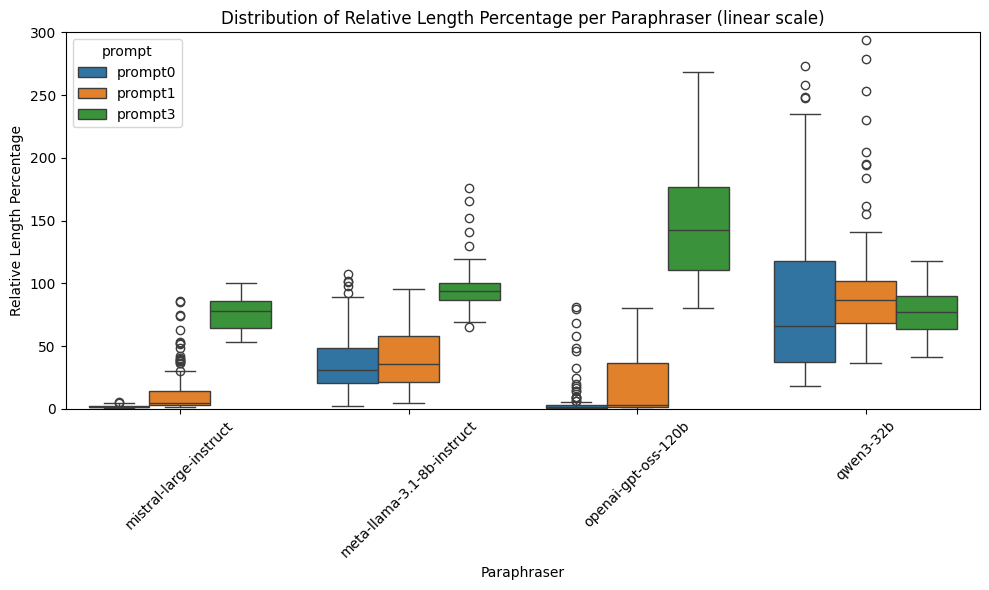

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/669466063.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 300)


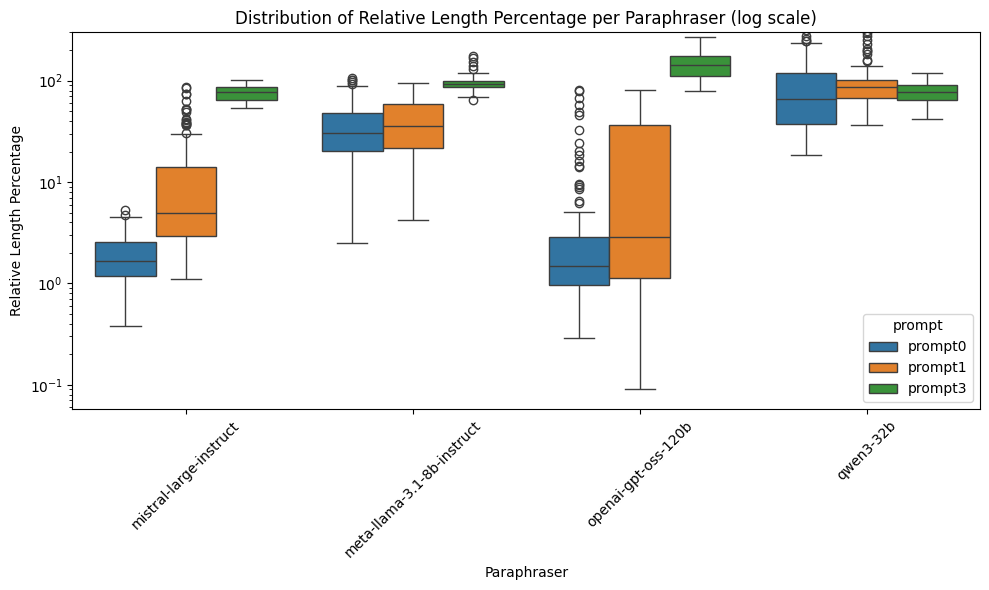

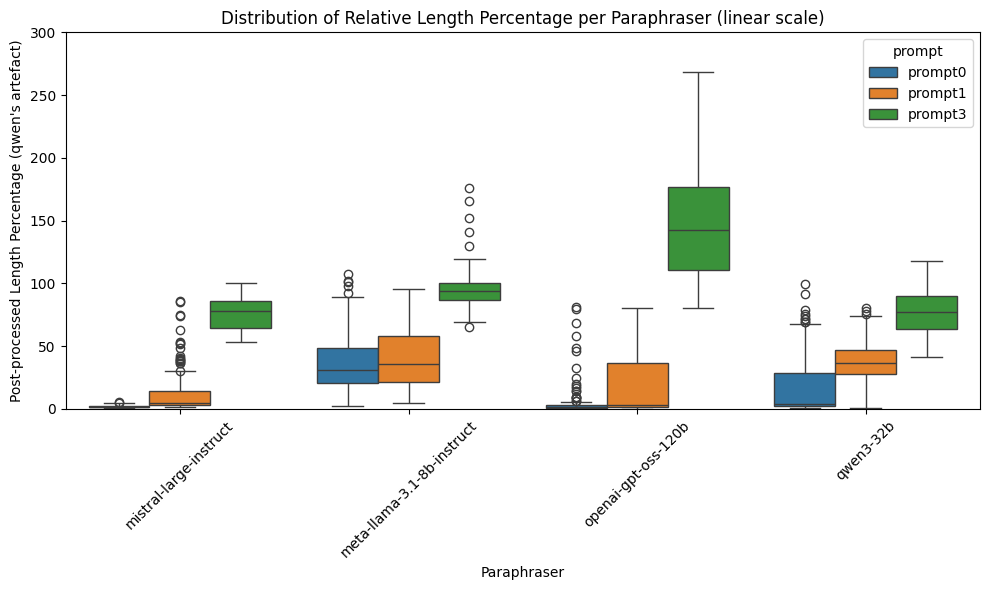

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/669466063.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 300)


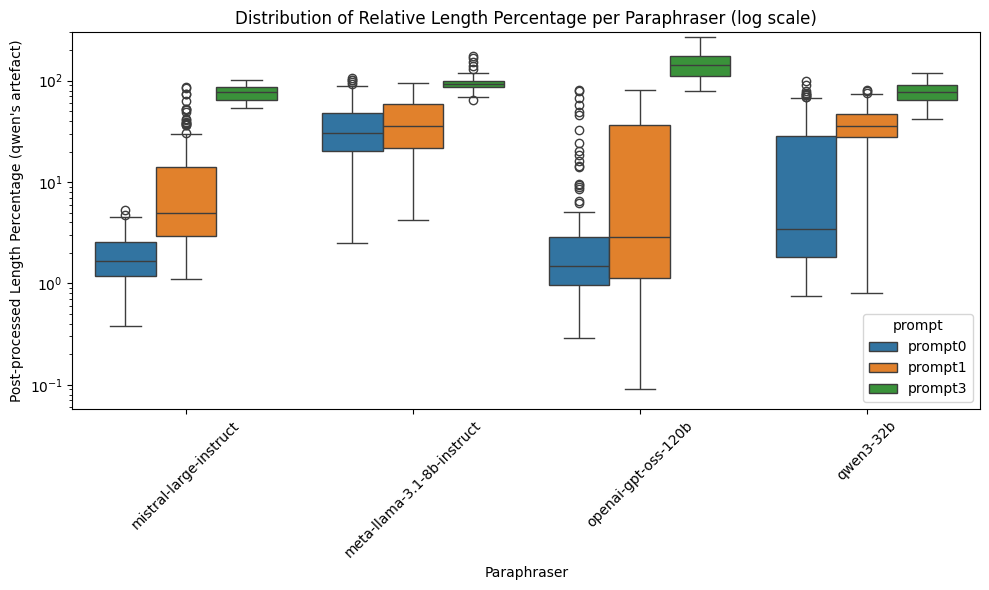

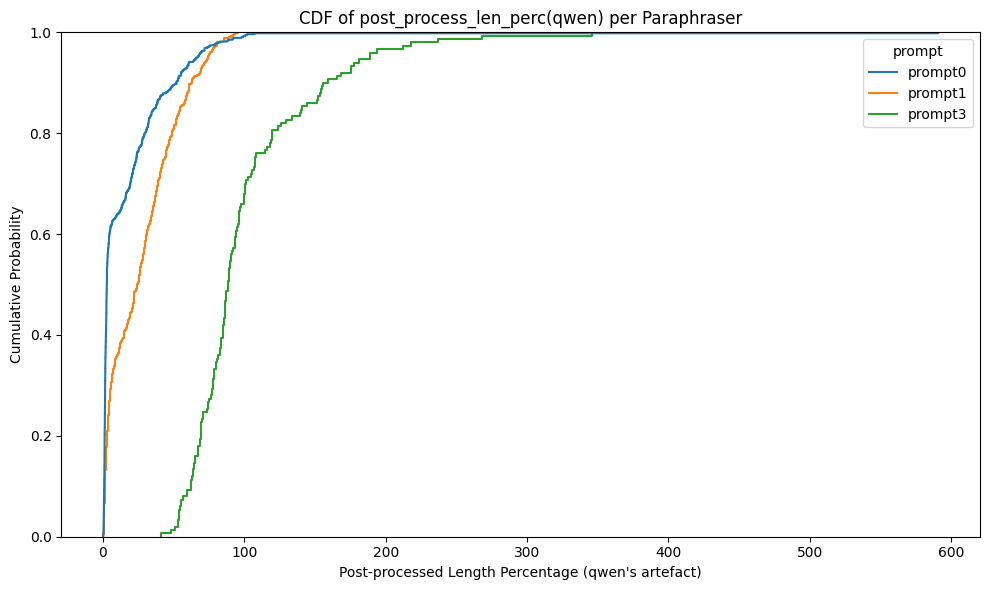

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for y_col in [
    "realtive_len_perc",
    "post_process_len_perc(qwen)",
]:
    for scale in ["linear", "log"]:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x="paraphraser", y=y_col, data=store_length, hue="prompt")

        if scale == "log":
            plt.yscale("log")  # log scale to expand lower region
        plt.title(
            f"Distribution of Relative Length Percentage per Paraphraser ({scale} scale)"
        )
        plt.xlabel("Paraphraser")
        plt.ylabel(
            "Relative Length Percentage"
            if y_col == "realtive_len_perc"
            else "Post-processed Length Percentage (qwen's artefact)"
        )
        plt.xticks(rotation=45)
        plt.ylim(0, 300)
        plt.tight_layout()
        plt.show()
        plt.close()


plt.figure(figsize=(10, 6))
sns.ecdfplot(
    data=store_length,
    x="post_process_len_perc(qwen)",
    hue="prompt",
    # col="paraphraser",  # facet by paraphraser
)
plt.title(f"CDF of post_process_len_perc(qwen) per Paraphraser")
plt.xlabel(
    "Relative Length Percentage"
    if y_col == "realtive_len_perc"
    else "Post-processed Length Percentage (qwen's artefact)"
)
plt.ylabel("Cumulative Probability")
plt.tight_layout()
plt.show()
plt.close()

In [41]:
import numpy as np

gt_store_length = (
    store_length[
        ["paraphraser", "prompt", "realtive_len_perc", "post_process_len_perc(qwen)"]
    ]
    .groupby(["paraphraser", "prompt"])
    .agg(
        mean_relative_len_perc=("realtive_len_perc", "mean"),
        std_relative_len_perc=("realtive_len_perc", "std"),
        mean_processed_qwen=("post_process_len_perc(qwen)", "mean"),
        std_processed_qwen=("post_process_len_perc(qwen)", "std"),
        count=("realtive_len_perc", "size"),
    )
    .reset_index()
)

# round floats for readability
gt_store_length = gt_store_length.applymap(
    lambda x: np.round(x, 2) if isinstance(x, float) else x
)
gt_store_length

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/1686632798.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  gt_store_length = gt_store_length.applymap(


,paraphraser,prompt,mean_relative_len_perc,std_relative_len_perc,mean_processed_qwen,std_processed_qwen,count
0,meta-llama-3.1-8b-instruct,prompt0,39.93,52.64,39.93,52.64,135
1,meta-llama-3.1-8b-instruct,prompt1,40.27,24.21,40.27,24.21,124
2,meta-llama-3.1-8b-instruct,prompt3,98.24,25.65,98.24,25.65,37
3,mistral-large-instruct,prompt0,1.89,1.00,1.89,1.00,138
4,mistral-large-instruct,prompt1,13.09,17.96,13.09,17.96,129
5,mistral-large-instruct,prompt3,75.28,13.15,75.28,13.15,36
6,openai-gpt-oss-120b,prompt0,5.53,13.47,5.53,13.47,139
7,openai-gpt-oss-120b,prompt1,19.21,25.00,19.21,25.00,129
8,openai-gpt-oss-120b,prompt3,150.43,55.28,150.43,55.28,38
9,qwen3-32b,prompt0,88.36,70.02,18.68,24.09,134


Relative length is computed as $\frac{len(paraphrase)}{len(reference)}\times 100\%$.

```python
(para_len / ref_len) * 100
```
Hence, a relative length of 100% means that the paraphrase has the same length as the reference. 
A relative length of 50% means that the paraphrase is half as long as the reference, and a relative length of 200% means that the paraphrase is twice as long as the reference.

_Count_ denotes the number of samples considered for the statistics.

We computed mean and standard deviation of the relative lengths per paraphraser and prompt.
All statistics are computed on samples from the Student Essay dataset (where candidates and disputed texts are authored by humans).

The qwen related measures/ columns differ for `qwen3-32b`since we found a pattern in generated text which we filtered out resulting in valid paraphrases which are way shorter than the original paraphrase (which contained chain-of-thought).

In [42]:
save_path = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "post_hoc_paraphrase_analysis"
)
save_path.mkdir(parents=True, exist_ok=True)
gt_store_length.to_csv(
    save_path / "relative_length_perc_per_paraphraser_prompt.csv", index=False
)
print("Saved to", save_path / "relative_length_perc_per_paraphraser_prompt.csv")

Saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/post_hoc_paraphrase_analysis/relative_length_perc_per_paraphraser_prompt.csv


Are the longest `qwen3-32b` paraphrases of low quality?

Yes, they contain the step-by-step process of replacing words with synonyms.

In [43]:
qwen_extremes = extremest_len_paraphrases[
    extremest_len_paraphrases["paraphraser"] == "qwen3-32b"
]
print("Number of long qwen3-32b paraphrases:", len(qwen_extremes))
print(qwen_extremes.columns)

top_qwen = qwen_extremes.sort_values(by="paraphrase_length", ascending=False)[
    ["paraphrase", "paraphrase_length"]
].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]

    # show first and last 100 characters
    print("Number of words:", l)
    print(
        textwrap.fill(p[:100], width=80), "...\n...", textwrap.fill(p[-100:], width=80)
    )
    print("-" * 80)

Number of long qwen3-32b paraphrases: 58
Index(['reference_text_length', 'paraphrase_length', 'smaller700',
       'paraphraser', 'reference_pair_id', 'pair_id', 'realtive_len_perc',
       'prompt', 'paraphrase'],
      dtype='object')
Number of words: 3950
<think> Okay, let's tackle this. The user wants me to paraphrase the given text
by identifying the m ...
... n grammar. I’m not very skilled in that area, haha, but it’s crucial when
learning a language. Done.
--------------------------------------------------------------------------------
Number of words: 3382
<think> Okay, let's start by reading the original text carefully. The user wants
me to paraphrase th ...
... earn Spanish as needed. Really worried. I want to, but what if I can’t? Staying
positive is so hard.
--------------------------------------------------------------------------------
Number of words: 3094
<think> Okay, let's tackle this. The user wants me to paraphrase a given
sentence by identifying the ...
... one so

Are perfect paraphrases (in terms of length) of low quality? 
We use this as a heuristic for paraphrases of similar length as the reference.

4 out of 5 perfect paraphrases (in terms of length) generated by `qwen3-32b` include a `</think>`.
Before this sign all text is chain-of-thought explaining how to replace words with synonyms.
After this sign the actual paraphrase starts.

In [ ]:
qwen_perfects = perfect_paraphrases[
    (perfect_paraphrases["paraphraser"] == "qwen3-32b")
    & (perfect_paraphrases["prompt"] != "prompt3")
]
print("Number of long qwen3-32b paraphrases:", len(qwen_perfects))

top_qwen = qwen_perfects[["paraphrase", "paraphrase_length"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]

    # show first and last 100 characters
    print("Number of words:", l)
    print(
        textwrap.fill(p[:100], width=80), "...\n...", textwrap.fill(p[-100:], width=80)
    )
    print("-" * 80)

Number of long qwen3-32b paraphrases: 29
Number of words: 725
<think> Okay, let me try to tackle this. The user wants me to paraphrase the
given text without chan ...
... ashy tramp, not Susan. And Ringo? He’d chosen her not for science, but for her
carnal charm. Period.
--------------------------------------------------------------------------------
Number of words: 796
<think> Okay, let me start by understanding what the user is asking. They want a
paraphrased version ...
... with music, laughter, and the scent of pot as two silhouettes of young women
emerged, holding hands.
--------------------------------------------------------------------------------
Number of words: 813
<think> Okay, let's tackle this. The user wants me to paraphrase their original
text by identifying ...
... I’m eager to finish, wondering if anyone truly cares about my thoughts—unless
they’re psychologists.
--------------------------------------------------------------------------------
Number of words: 824
<th

Try omitting `</think>` and the text before it from the paraphrase.

In [45]:
import textwrap

# Post-process the paraphrase text
qwen_perfects["post_processed_text"] = qwen_perfects.apply(
    lambda row: (
        row["paraphrase"].split("</think>")[-1].strip()
        if "</think>" in row["paraphrase"]
        else row["paraphrase"]
    ),
    axis=1,
)

# Select top 5 by length (or just first 5 rows)
top_qwen = qwen_perfects[["post_processed_text", "paraphrase_length"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["post_processed_text"]
    l = len(p.split())

    print(
        "Number of words before/ after processing:", row["paraphrase_length"], " / ", l
    )
    print("-" * 80)
    # wrap full text every 80 characters
    print(textwrap.fill(p, width=80))
    print("=" * 80)
    print("=" * 80)

Number of words before/ after processing: 725  /  258
--------------------------------------------------------------------------------
Susan glared at Irene, seething, aware that Irene would siphon the accolades for
their accidental breakthrough—monkey sperm that amplified human muscle mass—a
phenomenon both unprecedented and controversial among certain medical experts.
Susan craved the recognition, the prestige, the very substance she’d spent eight
years at Warford Labs perfecting through her studies on equine jockeys. She’d
dosed them with copious monkey sperm to boost training, leveraging the lab’s
ties to racetrack royalty like Ringo Bonkers and his steed Sebastian’s Carriage,
alongside Dr. Wilfy Ruggles and his champion Diaper Delivery. When Irene, the
backstabbing harlot, attempted to hijack Susan’s discovery, she knew she had to
crush her. Irene had long targeted Ringo, Susan’s ex-lover, who’d become
untouchable after his Frankfurt Derby Downs victory last summer. His horse, a
d

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_84037/3848094270.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qwen_perfects["post_processed_text"] = qwen_perfects.apply(


Are Long processed prompts with prompt 1 good?

They are okay in terms of content but way too short!

In [ ]:
qwen_processed_extremes = extremest_post_processed_len_paraphrases[
    (extremest_post_processed_len_paraphrases["paraphraser"] == "qwen3-32b")
    & (extremest_post_processed_len_paraphrases["prompt"] != "prompt3")
]
print("Number of long qwen3-32b paraphrases:", len(qwen_processed_extremes))
print(qwen_processed_extremes.columns)
top_qwen = qwen_processed_extremes.sort_values(
    by="post_process_len_perc(qwen)", ascending=False
)[["paraphrase", "post_process_len_perc(qwen)"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["post_process_len_perc(qwen)"]

    # show first and last 100 characters
    print("Number of words:", len(p.split()))
    print(
        textwrap.fill(p[:200], width=80), "...\n...", textwrap.fill(p[-200:], width=80)
    )

Number of long qwen3-32b paraphrases: 83
Index(['reference_text_length', 'paraphrase_length', 'smaller700',
       'paraphraser', 'reference_pair_id', 'pair_id', 'realtive_len_perc',
       'prompt', 'paraphrase', 'post_process_len_perc(qwen)'],
      dtype='object')
Number of words: 57
Maddie realized she was on the verge of a monumental scientific discovery, one
that could upend existing theories and shake the academic world, yet the ticking
clock and Sarah’s anxious gaze threatene ...
... clock and Sarah’s anxious gaze threatened to derail her focus as they secretly
toiled in the lab, determined to succeed despite the risks, until the husband’s
unexpected return revealed their triumph.
Number of words: 70
I am seated here contemplating that I had a subject to write about but instead I
have this. my thoughts. me. well to start it off my roommates in my living room
are blasting the tv and I am reluctant ...
... om are blasting the tv and I am reluctant to ask them to lower the volume 

Explore prompt 3 paraphrases.

In [ ]:
qwen_perfects = perfect_paraphrases[
    (perfect_paraphrases["paraphraser"] == "qwen3-32b")
    & (perfect_paraphrases["prompt"] == "prompt3")
]
print("Number of perfect qwen3-32b paraphrases:", len(qwen_perfects))

top_qwen = qwen_perfects[["paraphrase", "paraphrase_length"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]

    # show first and last 100 characters
    print("Number of words:", l)
    print(
        textwrap.fill(p[:400], width=80), "...\n...", textwrap.fill(p[-400:], width=80)
    )
    print("-" * 80)

Number of perfect qwen3-32b paraphrases: 9
Number of words: 1014
  Well, good day to you, my glowing screen. Isn’t it a delightful twist of fate
that I’ve finally sat down to conquer this psychology assignment before the
deadline looms over me like a thundercloud? Kudos to me, Molly, for this rare
act of self-discipline. Tonight, I’ve been lounging in a cozy haze while binge-
watching *Gilmore Girls*, a guilty pleasure that somehow manages to make even
mundane e ...
...  the hum of a haunted laptop. And if my screen decides to delete another line of
my masterpiece, well, I’ll just call it poetic justice and start over. After
all, life is a mess, but at least it’s my mess. Now, if only my laptop would
stop acting like it’s been possessed by a vengeful ghost, I might actually
finish this on time. Ciao, screen. Buona notte, and may your circuits be ever in
my favor.
--------------------------------------------------------------------------------
Number of words: 859
  Maddie’s heart raced

In [48]:
processed_extremes = extremest_post_processed_len_paraphrases[
    (extremest_post_processed_len_paraphrases["prompt"] == "prompt3")
]
print("Number of long/short paraphrases:", len(processed_extremes))
print(processed_extremes.columns)
top_extremes = processed_extremes.sort_values(
    by="post_process_len_perc(qwen)", ascending=False
)[["paraphrase", "post_process_len_perc(qwen)"]]
if len(top_extremes) >= 4:
    top_extremes = top_extremes.iloc[[0, 1, -2, -1]]

for _, row in top_extremes.iterrows():
    p = row["paraphrase"]
    l = row["post_process_len_perc(qwen)"]

    # show first and last 100 characters
    print("Number of words/ processed relative to reference:", len(p.split()), "/", l)
    print(
        textwrap.fill(p[:300], width=80), "...\n...", textwrap.fill(p[-300:], width=80)
    )

Number of long/short paraphrases: 5
Index(['reference_text_length', 'paraphrase_length', 'smaller700',
       'paraphraser', 'reference_pair_id', 'pair_id', 'realtive_len_perc',
       'prompt', 'paraphrase', 'post_process_len_perc(qwen)'],
      dtype='object')
Number of words/ processed relative to reference: 2553 / 345.93
Long ago, in a modest town that lay between rolling hills and a bustling river,
two girls entered the world on almost the same day and grew up only a few houses
apart, yet the worlds they inhabited could not have been more dissimilar. The
first, Maria, was born into a family whose wealth was evident ...
...  of one’s own deeds—remains vulnerable to the shadows cast by personal ambition.
The tale warns that when competition eclipses collaboration, even the most noble
of scientific endeavors can be twisted into instruments of personal gain,
leaving behind a trail of broken trust and unanswered questions.
Number of words/ processed relative to reference: 1978 / 268.02

In [ ]:
closest_to_100 = (
    store_length.loc[(store_length["prompt"] == "prompt3")]
    .assign(abs_diff=(store_length["post_process_len_perc(qwen)"] - 100).abs())
    .sort_values("abs_diff")
)

display(closest_to_100)

,paraphraser,prompt,reference_text_length,paraphrase_length,smaller700,reference_pair_id,pair_id,realtive_len_perc,post_process_len_perc(qwen),abs_diff
1193,meta-llama-3.1-8b-instruct,prompt3,801,800,False,2,0,99.88,99.88,0.12
1165,meta-llama-3.1-8b-instruct,prompt3,801,803,False,2,0,100.25,100.25,0.25
1099,openai-gpt-oss-120b,prompt3,1038,1033,False,0,0,99.52,99.52,0.48
1059,openai-gpt-oss-120b,prompt3,1038,1033,False,0,0,99.52,99.52,0.48
1132,mistral-large-instruct,prompt3,738,742,False,1,0,100.54,100.54,0.54
...,...,...,...,...,...,...,...,...,...,...
1131,openai-gpt-oss-120b,prompt3,738,1568,False,1,0,212.47,212.47,112.47
1127,openai-gpt-oss-120b,prompt3,738,1607,False,1,0,217.75,217.75,117.75
1123,openai-gpt-oss-120b,prompt3,738,1751,False,1,0,237.26,237.26,137.26
1135,openai-gpt-oss-120b,prompt3,738,1978,False,1,0,268.02,268.02,168.02
